In [2]:
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import networkx as nx
from scipy.spatial import distance_matrix

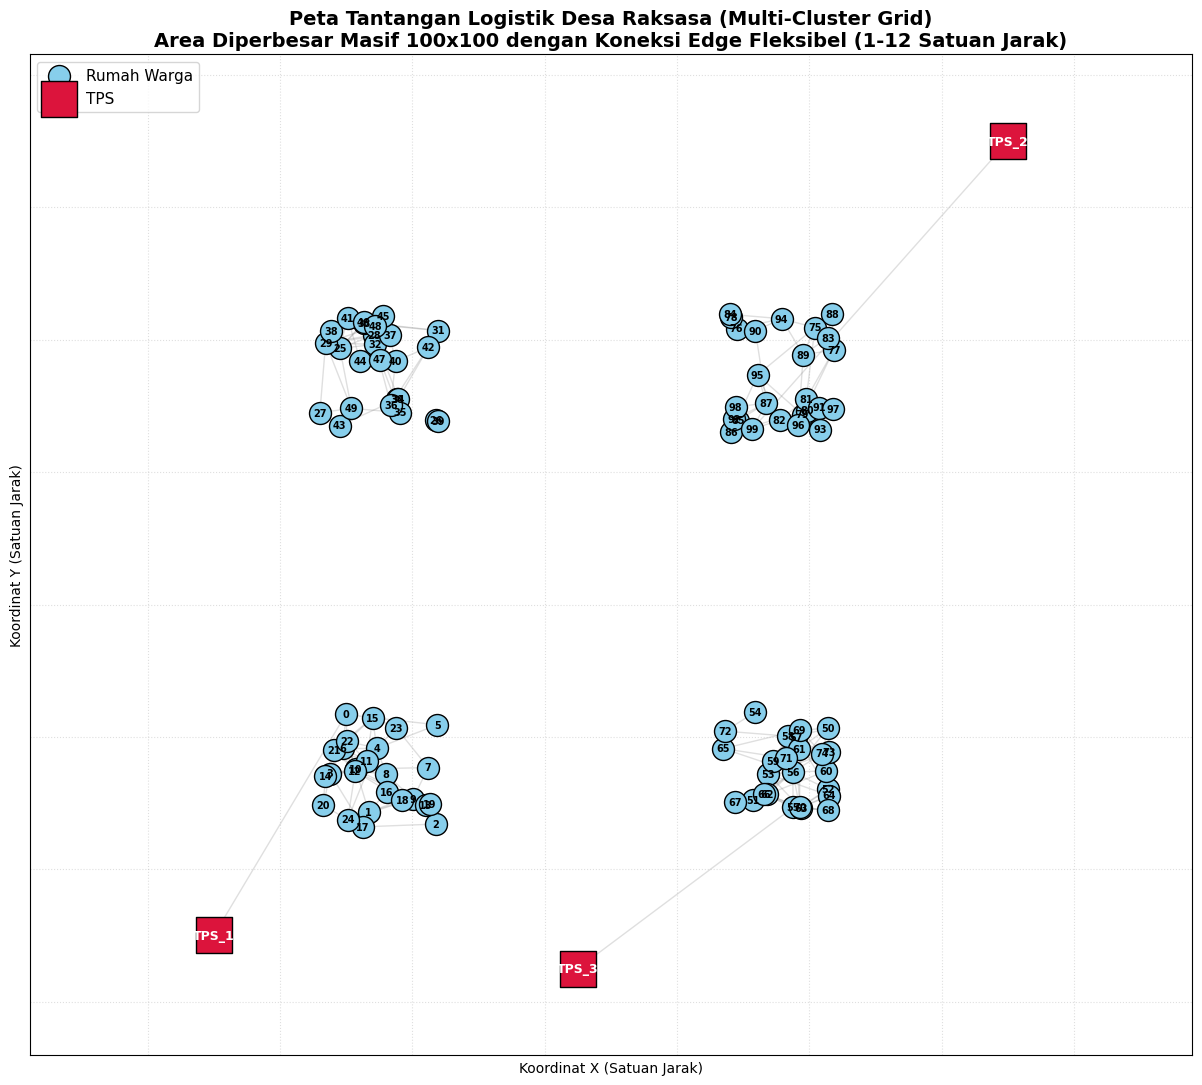

[*] Total Beban Sampah Desa Hari Ini: 322 KG
  Nama_Lokasi  Koordinat_X  Koordinat_Y  Volume_Sampah_KG
0       TPS_1       -10.00       -10.00                 0
1       TPS_2       110.00       110.00                 0
2       TPS_3        45.00       -15.00                 0
3     Rumah_0         9.95        23.40                 4
4     Rumah_1        13.43         8.69                 6
5     Rumah_2        23.58         6.84                 0
6     Rumah_3         7.60        14.47                 3
7     Rumah_4        14.63        18.29                 5


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.spatial import distance_matrix

# =====================================================================
# 1. INISIALISASI PARAMETER & SEED (DESA SKALA BESAR / MULTI-CLUSTER)
# =====================================================================
np.random.seed(2026)  # Menggunakan tahun tugas besar sebagai seed
jumlah_rumah = 100

# Untuk memperbesar area komplek secara masif, kita bagi 100 rumah ke dalam 4 Sub-Komplek Terpisah
# Luas total area peta sekarang membengkak dari 40x40 menjadi 100x100 satuan jarak
pusat_kluster = [
    (15.0, 15.0),   # Komplek A (Kiri Bawah)
    (15.0, 75.0),   # Komplek B (Kiri Atas)
    (75.0, 15.0),   # Komplek C (Kanan Bawah)
    (75.0, 75.0)    # Komplek D (Kanan Atas)
]

x_perumahan = []
y_perumahan = []

# Distribusikan 25 rumah untuk masing-masing sub-komplek agar sebaran lokal tetap padat
for cluster_idx, (cx, cy) in enumerate(pusat_kluster):
    # Setiap sub-komplek menyebar dalam radius kecil (0 s.d 18 satuan)
    x_res = np.random.uniform(cx - 9, cx + 9, 25)
    y_res = np.random.uniform(cy - 9, cy + 9, 25)
    x_perumahan.extend(x_res)
    y_perumahan.extend(y_res)

x_perumahan = np.array(x_perumahan)
y_perumahan = np.array(y_perumahan)

# Satukan menjadi dictionary koordinat rumah
posisi_rumah = {i: (round(x_perumahan[i], 2), round(y_perumahan[i], 2)) for i in range(jumlah_rumah)}

# Generate volume sampah acak 0 - 7 kg untuk setiap rumah
sampah_rumah = {i: np.random.randint(0, 8) for i in range(jumlah_rumah)}

# 3. GENERATE KOORDINAT 3 TPS STRATEGIS (Diletakkan di ujung terluar batas komplek raksasa)
posisi_tps = {
    'TPS_1': (-10.0, -10.0),   # Pojok Kiri Bawah Luar
    'TPS_2': (110.0, 110.0),   # Pojok Kanan Atas Luar
    'TPS_3': (45.0, -15.0)     # Tengah Bawah Terisolasi
}

# Gabungkan semua koordinat (Rumah + TPS) ke dalam satu master database koordinat
master_koordinat = {}
master_koordinat.update(posisi_tps)
for k, v in posisi_rumah.items():
    master_koordinat[f"Rumah_{k}"] = v

# =====================================================================
# 4. MEMBUAT GRAF DAN KONEKSI JALUR ADJACENCY (MULTI-RANGE EDGES)
# =====================================================================
G = nx.Graph()

# Tambahkan node rumah & TPS ke dalam objek graf beserta atributnya
for r_id, pos in posisi_rumah.items():
    G.add_node(f"Rumah_{r_id}", pos=pos, type='rumah', sampah=sampah_rumah[r_id])
for tps_id, pos in posisi_tps.items():
    G.add_node(tps_id, pos=pos, type='tps', sampah=0)

# Hitung matriks jarak Euclidean antarrumah
coords_list = np.array(list(posisi_rumah.values()))
dist_mat = distance_matrix(coords_list, coords_list)

for i in range(jumlah_rumah):
    # Logika Sambungan Jalan Berlapis:
    for j in range(i + 1, jumlah_rumah):
        jarak_ij = dist_mat[i][j]

        # ATURAN 1: Koneksi internal sub-komplek wajib mematuhi jarak ketat 1 s.d 5 satuan
        if 1.0 <= jarak_ij <= 5.5:
            G.add_edge(f"Rumah_{i}", f"Rumah_{j}")

        # ATURAN 2: Koneksi jembatan penghubung antar sub-komplek yang luas (diijinkan berjarak hingga 12 satuan)
        # Ini ditambahkan agar agen memiliki jalur lintas komplek tanpa terisolasi satu sama lain
        elif 5.5 < jarak_ij <= 12.0:
            # Membatasi jumlah jembatan lintas komplek agar graf tidak terlalu padat (Brute-Force blocker)
            if np.random.rand() < 0.15:
                G.add_edge(f"Rumah_{i}", f"Rumah_{j}")

# Menghubungkan 3 TPS ke rumah perbatasan terdekat di masing-masing sektor
G.add_edge('TPS_1', 'Rumah_0')      # Akses Komplek Kiri Bawah
G.add_edge('TPS_2', f'Rumah_{jumlah_rumah-1}')  # Akses Komplek Kanan Atas
G.add_edge('TPS_3', 'Rumah_55')     # Akses Jalan Pintas Tengah

# =====================================================================
# 5. VISUALISASI GRAF DESA SKALA BESAR MENGGUNAKAN MATPLOTLIB
# =====================================================================
plt.figure(figsize=(15, 13))
pos_all = nx.get_node_attributes(G, 'pos')

nodes_rumah = [n for n, attr in G.nodes(data=True) if attr['type'] == 'rumah']
nodes_tps = [n for n, attr in G.nodes(data=True) if attr['type'] == 'tps']

# Gambar jalan/edges (Garis putus-putus abu-abu menunjukkan rute peta inter-blok)
nx.draw_networkx_edges(G, pos_all, alpha=0.25, edge_color='gray')

# Gambar Rumah (Ukuran seragam = 250 agar muat proporsional di area peta luas)
nx.draw_networkx_nodes(G, pos_all, nodelist=nodes_rumah, node_color='skyblue',
                       node_size=250, edgecolors='black', label='Rumah Warga')

# Gambar TPS (Kotak merah besar)
nx.draw_networkx_nodes(G, pos_all, nodelist=nodes_tps, node_color='crimson', node_shape='s',
                       node_size=650, edgecolors='black', label='TPS')

# Label ID rumah warga
labels_rumah = {n: f"{n.split('_')[1]}" for n in nodes_rumah}
nx.draw_networkx_labels(G, pos_all, labels=labels_rumah, font_size=7, font_weight='bold', font_color='black')

labels_tps = {n: n for n in nodes_tps}
nx.draw_networkx_labels(G, pos_all, labels=labels_tps, font_size=9, font_weight='bold', font_color='white')

plt.title("Peta Tantangan Logistik Desa Raksasa (Multi-Cluster Grid)\nArea Diperbesar Masif 100x100 dengan Koneksi Edge Fleksibel (1-12 Satuan Jarak)",
          fontsize=14, fontweight='bold')
plt.xlabel("Koordinat X (Satuan Jarak)")
plt.ylabel("Koordinat Y (Satuan Jarak)")
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.4)
plt.axis('equal')
plt.show()

# =====================================================================
# 6. MENYIMPAN DATABASE KOORDINAT BARU KE FILE CSV
# =====================================================================
df_master = pd.DataFrame([
    {"Nama_Lokasi": nama, "Koordinat_X": pos[0], "Koordinat_Y": pos[1], "Volume_Sampah_KG": sampah_rumah[int(nama.split('_')[1])] if "Rumah" in nama else 0}
    for nama, pos in master_koordinat.items()
])


print(f"[*] Total Beban Sampah Desa Hari Ini: {sum(sampah_rumah.values())} KG")
print(df_master.head(8))

In [28]:
# ==========================================
# 1. PEMBAGIAN ZONA (CLUSTERING) MENGGUNAKAN K-MEANS
# ==========================================

# Ambil data koordinat rumah dari dictionary yang sudah dibuat sebelumnya
X_coords = np.array([posisi_rumah[i] for i in range(jumlah_rumah)])

# Zona untuk 5 Gerobak
kmeans_gerobak = KMeans(n_clusters=5, random_state=2026, n_init=10).fit(X_coords)
zona_gerobak_rumah = kmeans_gerobak.labels_  # Array berisi ID zona (0 s.d 4) untuk tiap rumah

# Zona untuk 2 Truk
kmeans_truk = KMeans(n_clusters=2, random_state=2026, n_init=10).fit(X_coords)
zona_truk_rumah = kmeans_truk.labels_      # Array berisi ID zona (0 s.d 1) untuk tiap rumah

# Update atribut node di graf G agar menyimpan data zonanya
for i in range(jumlah_rumah):
    G.nodes[f"Rumah_{i}"]['zona_gerobak'] = zona_gerobak_rumah[i]
    G.nodes[f"Rumah_{i}"]['zona_truk'] = zona_truk_rumah[i]

# ==========================================
# 2. INISIALISASI STRUKTUR DATA LOG TRACKING (TABEL)
# ==========================================

# Tabel untuk mencatat riwayat pergerakan fisik dan perubahan volume sampah
log_pergerakan = []

def catat_log(waktu, tipe_armada, id_armada, status, lokasi, muatan, jarak_tempuh, keterangan):
    """Fungsi pembantu untuk memasukkan baris riwayat ke dalam log log_pergerakan"""
    jam = 6 + (waktu // 60)
    menit = waktu % 60
    timestamp = f"{str(jam).zfill(2)}:{str(menit).zfill(2)}"

    log_pergerakan.append({
        "Timestamp": timestamp,
        "Tipe_Armada": tipe_armada,
        "ID_Armada": id_armada,
        "Status_Aktivitas": status,
        "Lokasi_Saat_Ini": lokasi,
        "Muatan_Bak_(KG)": round(muatan, 2),
        "Jarak_Tambahan": round(jarak_tempuh, 2),
        "Keterangan": keterangan
    })

# ==========================================
# 3. KONDISI AWAL AGEN (STATE MACHINE SETUP)
# ==========================================

# Salin kondisi awal volume sampah rumah agar bisa dicicil/dikurangi secara real-time
sisa_sampah_rumah = {f"Rumah_{i}": G.nodes[f"Rumah_{i}"]['sampah'] for i in range(jumlah_rumah)}

# Inisialisasi Status Gerobak (Mulai jam 06.00 -> Menit ke-0)
# Semua gerobak mulai dari posisi awal TPS_1 sebagai pool depot
status_gerobak = {
    i: {
        "posisi": "TPS_1",
        "koordinat": posisi_tps["TPS_1"],
        "muatan": 0.0,
        "total_jarak": 0.0,
        "total_waktu": 0,
        "sibuk_sampai_menit": 0
    } for i in range(5) # 5 Gerobak (ID 0 s.d 4)
}

# Inisialisasi Status Truk (Mulai jam 08.00 -> Menit ke-120)
status_truk = {
    i: {
        "posisi": "TPS_2" if i == 0 else "TPS_3",
        "koordinat": posisi_tps["TPS_2"] if i == 0 else posisi_tps["TPS_3"],
        "muatan": 0.0,
        "total_jarak": 0.0,
        "total_waktu": 0,
        "sibuk_sampai_menit": 120 # Mengunci truk agar baru bergerak pada menit ke-120 (08.00)
    } for i in range(2) # 2 Truk (ID 0 s.d 1)
}

np.random.seed(2026)  # Mengunci seed tahun tubes agar hasil konsisten setiap kali di-run
kapasitas_maksimal_tps = {
    "TPS_1": float(np.random.randint(400, 501)),
    "TPS_2": float(np.random.randint(400, 501)),
    "TPS_3": float(np.random.randint(400, 501))
}

# Kapasitas penampungan real-time di 3 TPS (Batas 400-500 kg per hari)
tampungan_tps = {"TPS_1": 0.0, "TPS_2": 0.0, "TPS_3": 0.0}

def cari_tps_tersedia_terdekat(current_coord, current_muatan):
    """ Fungsi untuk mencari TPS terdekat dengan kapasitas masih tersedia. """
    # Asumsi: Setiap TPS memiliki batas tampungan harian, misalnya 500 kg.
    # Ini bisa disesuaikan.
    BATAS_TAMPUNG_TPS = 500.0

    tps_terdekat = None
    min_jarak = float('inf')

    for tps_id, tps_coord in posisi_tps.items():
        if tampungan_tps[tps_id] + current_muatan <= BATAS_TAMPUNG_TPS:
            jarak = hitung_jarak_euclidean(current_coord, tps_coord)
            if jarak < min_jarak:
                min_jarak = jarak
                tps_terdekat = tps_id
    return tps_terdekat, min_jarak

def hitung_jarak_euclidean(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

# =====================================================================
# REVISI ENGINE FINAL: ANTI-BOCOR SYSTEM (VIRTUAL BOOKING CAPACITY)
# =====================================================================

# Reset sisa sampah rumah warga sesuai data grid acak awal
sisa_sampah_rumah = {f"Rumah_{i}": G.nodes[f"Rumah_{i}"]['sampah'] for i in range(jumlah_rumah)}

# Mengunci kuota kapasitas acak TPS di rentang 400 - 500 KG secara ketat [cite: 11]
np.random.seed(2026)
kapasitas_maksimal_tps = {
    "TPS_1": float(np.random.randint(400, 501)),
    "TPS_2": float(np.random.randint(400, 501)),
    "TPS_3": float(np.random.randint(400, 501))
}

# tampungan_tps mencatat sampah yang SUDAH FISIK MASUK ke TPS
tampungan_tps = {"TPS_1": 0.0, "TPS_2": 0.0, "TPS_3": 0.0}

# FIX LOGIKA: booking_tps mencatat (Sampah Aktual + Sampah yang SEDANG DI JALAN menuju TPS tersebut)
booking_tps = {"TPS_1": 0.0, "TPS_2": 0.0, "TPS_3": 0.0}

status_gerobak = {}
for i in range(5):
    # Cari tahu koordinat pusat (centroid) dari zona gerobak ini
    titik_rumah_zona = [posisi_rumah[r] for r in range(jumlah_rumah) if zona_gerobak_rumah[r] == i]
    if titik_rumah_zona:
        centroid_x = np.mean([p[0] for p in titik_rumah_zona])
        centroid_y = np.mean([p[1] for p in titik_rumah_zona])
        centroid_zona = (centroid_x, centroid_y)
    else:
        centroid_zona = posisi_tps["TPS_1"]

    # Set TPS awal gerobak berdasarkan TPS yang paling dekat dengan zonanya
    tps_awal = min(posisi_tps.keys(), key=lambda t: hitung_jarak_euclidean(posisi_tps[t], centroid_zona))

    status_gerobak[i] = {
        "posisi": tps_awal,
        "koordinat": posisi_tps[tps_awal], # Mulai dari gerbang komplek terdekat!
        "muatan": 0.0,
        "total_jarak": 0.0,
        "sibuk_sampai_menit": 0,
        "status_aktif": True,
        "tps_tujuan_booking": None,
        "muatan_booked": 0.0
    }

# Status truk biarkan tersebar rata di pool TPS_2 dan TPS_3 harian
status_truk = {
    i: {
        "posisi": "TPS_2" if i == 0 else "TPS_3",
        "koordinat": posisi_tps["TPS_2"] if i == 0 else posisi_tps["TPS_3"],
        "muatan": 0.0, "total_jarak": 0.0, "sibuk_sampai_menit": 120, "status_aktif": True,
        "tps_tujuan_booking": None, "muatan_booked": 0.0
    } for i in range(2)
}
log_pergerakan = []

# PERBAIKAN FUNGSI NAVIGASI: Validasi didasarkan pada data booking_tps, BUKAN tampungan_tps aktual
def cari_tps_tersedia_terdekat(koordinat_sekarang, muatan_armada):
    tps_valid = []
    for tps_name, cap_max in kapasitas_maksimal_tps.items():
        # Memeriksa total akumulasi antrean di jalan agar kuota harian tidak jebol [cite: 11]
        if booking_tps[tps_name] + muatan_armada <= cap_max:
            tps_valid.append(tps_name)

    if not tps_valid:
        return None, None

    tps_terpilih = min(tps_valid, key=lambda t: hitung_jarak_euclidean(koordinat_sekarang, posisi_tps[t]))
    jarak = hitung_jarak_euclidean(koordinat_sekarang, posisi_tps[tps_terpilih])
    return tps_terpilih, jarak

# =====================================================================
# TIME-TRIGGERED SIMULATION CLOCK (06.00 - 17.00) [cite: 20, 21]
# =====================================================================
for menit_simulasi in range(661):

    # KONDISI EVALUASI GEROBAK / TRUK YANG SELESAI PERJALANAN KELUAR DARI STATE SIBUK
    # Jika armada hari ini dijadwalkan sampai di TPS pada menit_simulasi ini, konversikan kuota booking menjadi kuota aktual
    for g_id, g_data in status_gerobak.items():
        if menit_simulasi == g_data["sibuk_sampai_menit"] and g_data["tps_tujuan_booking"] is not None:
            tps_tujuan = g_data["tps_tujuan_booking"]
            tampungan_tps[tps_tujuan] += g_data["muatan_booked"]
            # Reset penanda booking internal agen
            g_data["tps_tujuan_booking"] = None
            g_data["muatan_booked"] = 0.0

    for t_id, t_data in status_truk.items():
        if menit_simulasi == t_data["sibuk_sampai_menit"] and t_data["tps_tujuan_booking"] is not None:
            tps_tujuan = t_data["tps_tujuan_booking"]
            tampungan_tps[tps_tujuan] += t_data["muatan_booked"]
            t_data["tps_tujuan_booking"] = None
            t_data["muatan_booked"] = 0.0

    # ----------------------------------------------------
    # A. SEKTOR UTAMA OPERASI GEROBAK (Batas 15.00) [cite: 20]
    # ----------------------------------------------------
    if menit_simulasi <= 540:
        for g_id, g_data in status_gerobak.items():
            if not g_data["status_aktif"] or menit_simulasi < g_data["sibuk_sampai_menit"]:
                continue

            sisa_waktu_g = 540 - menit_simulasi
            tps_dekat, jarak_tps = cari_tps_tersedia_terdekat(g_data["koordinat"], g_data["muatan"])

            if tps_dekat is None:
                continue

            rumah_target = [f"Rumah_{i}" for i in range(jumlah_rumah) if zona_gerobak_rumah[i] == g_id and sisa_sampah_rumah[f"Rumah_{i}"] > 0]

            pilih_pulang = False
            pilih_titip_truk = False
            truk_target_id = None
            koordinat_temu = None
            waktu_ke_temu_g = 0

            # Pengecekan Heuristik ROI Waktu Berdasarkan Trigger Muatan 80% usulanmu
            if g_data["muatan"] >= 12.0 or (len(rumah_target) == 0 and g_data["muatan"] > 0):
                truk_valid_temu = []
                for t_id, t_data in status_truk.items():
                    if t_data["status_aktif"] and menit_simulasi >= 120 and t_data["muatan"] < 200.0:
                        mid_x = (g_data["koordinat"][0] + t_data["koordinat"][0]) / 2
                        mid_y = (g_data["koordinat"][1] + t_data["koordinat"][1]) / 2
                        mid_coord = (round(mid_x, 2), round(mid_y, 2))

                        d_ke_mid_g = hitung_jarak_euclidean(g_data["koordinat"], mid_coord)
                        d_ke_mid_t = hitung_jarak_euclidean(t_data["koordinat"], mid_coord)

                        waktu_g_ke_mid = int(round(d_ke_mid_g * 2))
                        waktu_t_ke_mid = int(round(d_ke_mid_t * 2))

                        if d_ke_mid_g < jarak_tps:
                            tps_dekat_t, jarak_tps_t = cari_tps_tersedia_terdekat(mid_coord, t_data["muatan"] + 1.0)
                            if tps_dekat_t is not None:
                                waktu_t_pulang_dari_mid = int(round(((jarak_tps_t / 5) * 3) + 10))
                                sisa_waktu_t = 660 - menit_simulasi
                                if waktu_t_ke_mid + waktu_t_pulang_dari_mid <= sisa_waktu_t:
                                    truk_valid_temu.append((t_id, mid_coord, waktu_g_ke_mid, d_ke_mid_g))

                if truk_valid_temu:
                    truk_target_id, koordinat_temu, waktu_ke_temu_g, jarak_temu_g = min(truk_valid_temu, key=lambda x: x[3])
                    pilih_titip_truk = True
                else:
                    pilih_pulang = True
            else:
                waktu_pulang_g = int(round((jarak_tps * 2) + (g_data["muatan"] * 2)))
                if sisa_waktu_g <= waktu_pulang_g and g_data["muatan"] > 0:
                    pilih_pulang = True

            # ACTION 1: JANJI TEMU BERPAPASAN DI MIDPOINT KOORDINAT
            if pilih_titip_truk:
                t_data = status_truk[truk_target_id]
                kapasitas_sisa_truk = 200.0 - t_data["muatan"]
                sampah_dititip = min(g_data["muatan"], kapasitas_sisa_truk)
                waktu_load_transfer = int(round(sampah_dititip * 2))

                g_data["total_jarak"] += jarak_temu_g
                g_data["sibuk_sampai_menit"] = menit_simulasi + waktu_ke_temu_g + waktu_load_transfer
                g_data["koordinat"] = koordinat_temu
                g_data["posisi"] = f"Rendezvous_Truk_{truk_target_id}"
                g_data["muatan"] -= sampah_dititip

                t_data["total_jarak"] += hitung_jarak_euclidean(t_data["koordinat"], koordinat_temu)
                t_data["sibuk_sampai_menit"] = menit_simulasi + waktu_ke_temu_g + waktu_load_transfer
                t_data["koordinat"] = koordinat_temu
                t_data["posisi"] = f"Rendezvous_Gerobak_{g_id}"
                t_data["muatan"] += sampah_dititip

                catat_log(menit_simulasi, "Gerobak", g_id, "Titip di Midpoint", koordinat_temu, g_data["muatan"], jarak_temu_g,
                          f"Transfer potong seadanya {sampah_dititip} kg ke Truk {truk_target_id}")

            # ACTION 2: BERGERAK PULANG DAN MENGUTUS SISTEM VIRTUAL BOOKING KE TPS
            elif pilih_pulang:
                waktu_jalan = int(round(jarak_tps * 2))
                waktu_load = int(round(g_data["muatan"] * 2))
                total_durasi = waktu_jalan + waktu_load

                # FIX LOGIKA: Langsung kunci kuota booking_tps agar tidak bisa direbut kendaraan lain saat di jalan!
                booking_tps[tps_dekat] += g_data["muatan"]

                g_data["total_jarak"] += jarak_tps
                g_data["sibuk_sampai_menit"] = menit_simulasi + total_durasi
                g_data["koordinat"] = posisi_tps[tps_dekat]
                g_data["posisi"] = tps_dekat

                # Amankan data muatan ke pelacak booking internal agen
                g_data["tps_tujuan_booking"] = tps_dekat
                g_data["muatan_booked"] = g_data["muatan"]

                catat_log(menit_simulasi, "Gerobak", g_id, "Bongkar di TPS", tps_dekat, 0, jarak_tps,
                          f"Mengunci slot kuota dan bergerak menuju {tps_dekat}")
                g_data["muatan"] = 0.0

            # ACTION 3: AMKUT SAMPAH DI PERUMAHAN
            elif len(rumah_target) > 0 and g_data["muatan"] < 15.0:
                r_dekat = min(rumah_target, key=lambda r: hitung_jarak_euclidean(g_data["koordinat"], master_koordinat[r]))
                jarak = hitung_jarak_euclidean(g_data["koordinat"], master_koordinat[r_dekat])

                kapasitas_sisa = 15.0 - g_data["muatan"]
                sampah_diangkut = min(sisa_sampah_rumah[r_dekat], kapasitas_sisa)

                waktu_jalan = int(round(jarak * 2))
                waktu_load = int(round(sampah_diangkut * 2))
                total_durasi = waktu_jalan + waktu_load

                tps_baru, jarak_tps_baru = cari_tps_tersedia_terdekat(master_koordinat[r_dekat], g_data["muatan"] + sampah_diangkut)

                if tps_baru is not None:
                    waktu_pulang_prediksi = int(round((jarak_tps_baru * 2) + ((g_data["muatan"] + sampah_diangkut) * 2)))
                    if menit_simulasi + total_durasi + waktu_pulang_prediksi <= 540:
                        sisa_sampah_rumah[r_dekat] -= sampah_diangkut
                        g_data["muatan"] += sampah_diangkut
                        g_data["total_jarak"] += jarak
                        g_data["sibuk_sampai_menit"] = menit_simulasi + total_durasi
                        g_data["koordinat"] = master_koordinat[r_dekat]
                        g_data["posisi"] = r_dekat
                        catat_log(menit_simulasi, "Gerobak", g_id, "Angkut Sampah Warga", r_dekat, g_data["muatan"], jarak, f"Mengangkut {sampah_diangkut} kg")
                        continue

                # Jika tidak muat kuota atau kehabisan waktu, amankan sisa muatan aktual ke TPS terdekat yang muat sekarang
                booking_tps[tps_dekat] += g_data["muatan"]
                g_data["total_jarak"] += jarak_tps
                g_data["sibuk_sampai_menit"] = menit_simulasi + waktu_pulang_g
                g_data["koordinat"] = posisi_tps[tps_dekat]
                g_data["posisi"] = tps_dekat
                g_data["tps_tujuan_booking"] = tps_dekat
                g_data["muatan_booked"] = g_data["muatan"]
                g_data["muatan"] = 0.0
            else:
                g_data["status_aktif"] = False

    # ----------------------------------------------------
    # B. SEKTOR UTAMA OPERASI TRUK (Batas 17.00) [cite: 21]
    # ----------------------------------------------------
    if menit_simulasi >= 120:
        for t_id, t_data in status_truk.items():
            if not t_data["status_aktif"] or menit_simulasi < t_data["sibuk_sampai_menit"]:
                continue

            sisa_waktu_t = 660 - menit_simulasi
            tps_dekat, jarak_tps = cari_tps_tersedia_terdekat(t_data["koordinat"], t_data["muatan"])

            if tps_dekat is None:
                continue

            rumah_target_truk = [f"Rumah_{i}" for i in range(jumlah_rumah) if zona_truk_rumah[i] == t_id and sisa_sampah_rumah[f"Rumah_{i}"] > 0]

            pilih_pulang_truk = False
            if len(rumah_target_truk) == 0 and t_data["muatan"] > 0:
                pilih_pulang_truk = True
            elif t_data["muatan"] >= 160.0: # Trigger muatan 80% harian truk
                pilih_pulang_truk = True
            else:
                waktu_pulang_t = int(round(((jarak_tps / 5) * 3) + ((t_data["muatan"] / 10) * 2)))
                if sisa_waktu_t <= waktu_pulang_t and t_data["muatan"] > 0:
                    pilih_pulang_truk = True

            # ACTION TRUK: BERGERAK PULANG DAN MENGUTUS SISTEM VIRTUAL BOOKING KE TPS [cite: 10]
            if pilih_pulang_truk:
                waktu_jalan = int(round((jarak_tps / 5) * 3))
                waktu_load = int(round((t_data["muatan"] / 10) * 2))
                total_durasi = waktu_jalan + waktu_load

                # FIX LOGIKA: Langsung tandai kuota booking harian agar tidak jebol diserobot gerobak [cite: 11]
                booking_tps[tps_dekat] += t_data["muatan"]

                t_data["total_jarak"] += jarak_tps
                t_data["sibuk_sampai_menit"] = menit_simulasi + total_durasi
                t_data["koordinat"] = posisi_tps[tps_dekat]
                t_data["posisi"] = tps_dekat

                t_data["tps_tujuan_booking"] = tps_dekat
                t_data["muatan_booked"] = t_data["muatan"]

                catat_log(menit_simulasi, "Truk", t_id, "Bongkar di TPS", tps_dekat, 0, jarak_tps,
                          f"Truk mengunci slot kuota harian dan bergerak menuju {tps_dekat}")
                t_data["muatan"] = 0.0

            elif len(rumah_target_truk) > 0 and t_data["muatan"] < 200.0:
                r_dekat = min(rumah_target_truk, key=lambda r: hitung_jarak_euclidean(t_data["koordinat"], master_koordinat[r]))
                jarak = hitung_jarak_euclidean(t_data["koordinat"], master_koordinat[r_dekat])

                kapasitas_sisa = 200.0 - t_data["muatan"]
                sampah_diangkut = min(sisa_sampah_rumah[r_dekat], kapasitas_sisa)

                waktu_jalan = int(round((jarak / 5) * 3))
                waktu_load = int(round((sampah_diangkut / 10) * 2))
                total_durasi = waktu_jalan + waktu_load

                tps_baru, jarak_tps_baru = cari_tps_tersedia_terdekat(master_koordinat[r_dekat], t_data["muatan"] + sampah_diangkut)

                if tps_baru is not None:
                    waktu_pulang_prediksi = int(round(((jarak_tps_baru / 5) * 3) + (((t_data["muatan"] + sampah_diangkut) / 10) * 2)))
                    if menit_simulasi + total_durasi + waktu_pulang_prediksi <= 660:
                        sisa_sampah_rumah[r_dekat] -= sampah_diangkut
                        t_data["muatan"] += sampah_diangkut
                        t_data["total_jarak"] += jarak
                        t_data["sibuk_sampai_menit"] = menit_simulasi + total_durasi
                        t_data["koordinat"] = master_koordinat[r_dekat]
                        t_data["posisi"] = r_dekat
                        catat_log(menit_simulasi, "Truk", t_id, "Angkut Sampah Warga", r_dekat, t_data["muatan"], jarak, f"Truk mengambil {sampah_diangkut} kg")
                        continue

                booking_tps[tps_dekat] += t_data["muatan"]
                t_data["total_jarak"] += jarak_tps
                t_data["sibuk_sampai_menit"] = menit_simulasi + waktu_pulang_t
                t_data["koordinat"] = posisi_tps[tps_dekat]
                t_data["posisi"] = tps_dekat
                t_data["tps_tujuan_booking"] = tps_dekat
                t_data["muatan_booked"] = t_data["muatan"]
                t_data["muatan"] = 0.0
            else:
                t_data["status_aktif"] = False

# Bangun ulang hasil log aktivitas harian baru yang aman dari kebocoran
df_log_pergerakan = pd.DataFrame(log_pergerakan)


In [29]:
# =====================================================================
# REVISI CETAK: EVALUASI TRANSAPARANSI SEKTOR & KUOTA KETAT TPS
# =====================================================================

# Hitung sisa sampah khusus rumah warga berdasarkan Super Sektor tugas Truk
sisa_sektor_A = sum([sisa_sampah_rumah[f"Rumah_{i}"] for i in range(jumlah_rumah) if zona_truk_rumah[i] == 0])
sisa_sektor_B = sum([sisa_sampah_rumah[f"Rumah_{i}"] for i in range(jumlah_rumah) if zona_truk_rumah[i] == 1])

print("================================================================")
print("REPORT EVALUASI SISA SAMPAH DI PERUMAHAN WARGA")
print("================================================================")
print(f"1. Total Sisa Sampah di Sektor A (Truk 0) : {sisa_sektor_A} kg")
print(f"2. Total Sisa Sampah di Sektor B (Truk 1) : {sisa_sektor_B} kg")
print(f"3. Total Sisa Sampah di Dalam Bak Seluruh Gerobak     : {sum([g['muatan'] for g in status_gerobak.values()])} kg")
print(f"4. Total Sisa Sampah di Dalam Bak Seluruh Truk        : {sum([t['muatan'] for t in status_truk.values()])} kg")

print("\n================================================================")
print("PERBANDINGAN KUOTA ACAK TPS VS TOTAL SAMPAH AKTUAL YANG MASUK")
print("================================================================")
print(f"[*] TOTAL SAMPAH YANG BERHASIL DISELAMATKAN KE TPS: {sum(tampungan_tps.values())} kg\n")

for tps, isi in tampungan_tps.items():
    status_overload = "AMAN" if isi <= kapasitas_maksimal_tps[tps] else "!!! OVERLOAD / BOCOR !!!"
    print(f"-> {tps} :")
    print(f"   - Batas Kuota Maksimal Harian (Hasil Acak) : {kapasitas_maksimal_tps[tps]} kg ")
    print(f"   - Total Aktual Sampah yang Masuk          : {round(isi, 2)} kg")
    print(f"   - Status Keamanan Kontrol Dampak          : {status_overload}")
    print(f"   - Sisa Ruang Kosong Tampungan Terakhir     : {round(kapasitas_maksimal_tps[tps] - isi, 2)} kg\n")
print("================================================================")

REPORT EVALUASI SISA SAMPAH DI PERUMAHAN WARGA
1. Total Sisa Sampah di Sektor A (Truk 0) : 0.0 kg
2. Total Sisa Sampah di Sektor B (Truk 1) : 0 kg
3. Total Sisa Sampah di Dalam Bak Seluruh Gerobak     : 0.0 kg
4. Total Sisa Sampah di Dalam Bak Seluruh Truk        : 0.0 kg

PERBANDINGAN KUOTA ACAK TPS VS TOTAL SAMPAH AKTUAL YANG MASUK
[*] TOTAL SAMPAH YANG BERHASIL DISELAMATKAN KE TPS: 322.0 kg

-> TPS_1 :
   - Batas Kuota Maksimal Harian (Hasil Acak) : 401.0 kg 
   - Total Aktual Sampah yang Masuk          : 15.0 kg
   - Status Keamanan Kontrol Dampak          : AMAN
   - Sisa Ruang Kosong Tampungan Terakhir     : 386.0 kg

-> TPS_2 :
   - Batas Kuota Maksimal Harian (Hasil Acak) : 406.0 kg 
   - Total Aktual Sampah yang Masuk          : 156.0 kg
   - Status Keamanan Kontrol Dampak          : AMAN
   - Sisa Ruang Kosong Tampungan Terakhir     : 250.0 kg

-> TPS_3 :
   - Batas Kuota Maksimal Harian (Hasil Acak) : 426.0 kg 
   - Total Aktual Sampah yang Masuk          : 151.0 kg
   - Sta

In [30]:
# A. Menghitung Ringkasan Jarak Tempuh (Poin 1 & 2 dari Soal)
print("================================================================")
print("REPORT METRIK EFISIENSI PERJALANAN (UNTUK PAK KADES)")
print("================================================================")
total_jarak_truk = 0
for t_id, t_data in status_truk.items():
    print(f"-> Total Jarak Tempuh Truk ID {t_id} \t: {round(t_data['total_jarak'], 2)} satuan jarak")
    total_jarak_truk += t_data['total_jarak']

total_jarak_gerobak = 0
for g_id, g_data in status_gerobak.items():
    print(f"-> Total Jarak Tempuh Gerobak ID {g_id} : {round(g_data['total_jarak'], 2)} satuan jarak")
    total_jarak_gerobak += g_data['total_jarak']

print(f"\n[*] AKUMULASI TOTAL JARAK TRUK    : {round(total_jarak_truk, 2)} satuan jarak")
print(f"[*] AKUMULASI TOTAL JARAK GEROBAK : {round(total_jarak_gerobak, 2)} satuan jarak")

# B. Menghitung Sisa Sampah Setelah Waktu Operasional Selesai (Poin F dari Soal)
print("\n================================================================")
print("REPORT EVALUASI SISA SAMPAH DI AKHIR SHIFT OPERASIONAL")
print("================================================================")
sisa_di_warga = sum(sisa_sampah_rumah.values())
sisa_di_gerobak = sum([g_data["muatan"] for g_data in status_gerobak.values()])
sisa_di_truk = sum([t_data["muatan"] for t_data in status_truk.values()])

print(f"1. Total Sisa Sampah Tertinggal di Rumah Warga : {sisa_di_warga} kg")
print(f"2. Total Sisa Sampah di Dalam Bak Seluruh Gerobak: {sisa_di_gerobak} kg")
print(f"3. Total Sisa Sampah di Dalam Bak Seluruh Truk   : {sisa_di_truk} kg")
print(f"4. Total Sampah yang Berhasil Ditampung di 3 TPS : {sum(tampungan_tps.values())} kg")
for tps, isi in tampungan_tps.items():
    print(f"   - {tps} menampung harian sebesar : {round(isi, 2)} kg")

print("\n--- Cuplikan 10 Baris Pertama Tabel Tracking Pergerakan Real-Time ---")
print(df_log_pergerakan.head(10))


REPORT METRIK EFISIENSI PERJALANAN (UNTUK PAK KADES)
-> Total Jarak Tempuh Truk ID 0 	: 328.58 satuan jarak
-> Total Jarak Tempuh Truk ID 1 	: 315.11 satuan jarak
-> Total Jarak Tempuh Gerobak ID 0 : 218.15 satuan jarak
-> Total Jarak Tempuh Gerobak ID 1 : 83.28 satuan jarak
-> Total Jarak Tempuh Gerobak ID 2 : 112.52 satuan jarak
-> Total Jarak Tempuh Gerobak ID 3 : 145.3 satuan jarak
-> Total Jarak Tempuh Gerobak ID 4 : 92.23 satuan jarak

[*] AKUMULASI TOTAL JARAK TRUK    : 643.69 satuan jarak
[*] AKUMULASI TOTAL JARAK GEROBAK : 651.48 satuan jarak

REPORT EVALUASI SISA SAMPAH DI AKHIR SHIFT OPERASIONAL
1. Total Sisa Sampah Tertinggal di Rumah Warga : 0.0 kg
2. Total Sisa Sampah di Dalam Bak Seluruh Gerobak: 0.0 kg
3. Total Sisa Sampah di Dalam Bak Seluruh Truk   : 0.0 kg
4. Total Sampah yang Berhasil Ditampung di 3 TPS : 322.0 kg
   - TPS_1 menampung harian sebesar : 15.0 kg
   - TPS_2 menampung harian sebesar : 156.0 kg
   - TPS_3 menampung harian sebesar : 151.0 kg

--- Cuplikan 

In [31]:
# =====================================================================
# KODE TAMBAHAN: ANALISIS TIMESTAMP AKHIR OPERASIONAL ARMADA
# =====================================================================

print("================================================================")
print("ANALISIS WAKTU SELESAI OPERASIONAL REAL-TIME (JAM BONGKAR AKHIR)")
print("================================================================")

# 1. Filter Log Khusus Aktivitas "Bongkar di TPS" atau "Emergency Return" ke TPS
df_bongkar = df_log_pergerakan[df_log_pergerakan['Status_Aktivitas'].isin(['Bongkar di TPS', 'Emergency Return', 'Early Return (Zona Bersih)', 'Early Return'])]

print("[+] Waktu Selesai Bongkar Terakhir Seluruh Gerobak (Batas 15:00):")
for g_id in range(5):
    df_g_akhir = df_bongkar[(df_bongkar['Tipe_Armada'] == 'Gerobak') & (df_bongkar['ID_Armada'] == g_id)]

    if not df_g_akhir.empty:
        # Ambil baris terakhir aktivitas bongkar
        waktu_terakhir_str = df_g_akhir.iloc[-1]['Timestamp']
        print(f"    - Gerobak ID {g_id} selesai bongkar total pada pukul : {waktu_terakhir_str}")
    else:
        # Jika zona dari awal sudah bersih sekali jalan dan tidak perlu ke TPS lagi
        print(f"    - Gerobak ID {g_id} selesai tugas (Bak Kosong/Standby)  : 06:00")

print("\n[+] Waktu Selesai Bongkar Terakhir Seluruh Truk (Batas 17:00):")
for t_id in range(2):
    df_t_akhir = df_bongkar[(df_bongkar['Tipe_Armada'] == 'Truk') & (df_bongkar['ID_Armada'] == t_id)]

    if not df_t_akhir.empty:
        waktu_terakhir_str = df_t_akhir.iloc[-1]['Timestamp']
        print(f"    - Truk ID {t_id} selesai bongkar total pada pukul    : {waktu_terakhir_str}")
    else:
        print(f"    - Truk ID {t_id} selesai tugas (Bak Kosong/Standby)     : 08:00")

print("================================================================")


ANALISIS WAKTU SELESAI OPERASIONAL REAL-TIME (JAM BONGKAR AKHIR)
[+] Waktu Selesai Bongkar Terakhir Seluruh Gerobak (Batas 15:00):
    - Gerobak ID 0 selesai bongkar total pada pukul : 07:52
    - Gerobak ID 1 selesai bongkar total pada pukul : 07:55
    - Gerobak ID 2 selesai bongkar total pada pukul : 09:44
    - Gerobak ID 3 selesai tugas (Bak Kosong/Standby)  : 06:00
    - Gerobak ID 4 selesai tugas (Bak Kosong/Standby)  : 06:00

[+] Waktu Selesai Bongkar Terakhir Seluruh Truk (Batas 17:00):
    - Truk ID 0 selesai bongkar total pada pukul    : 13:40
    - Truk ID 1 selesai bongkar total pada pukul    : 10:36
